# Heart Rate Interval Segmentation

Detects workout interval boundaries using only HR data.

**Just run all cells from top to bottom!**

## 1. Install Dependencies (Run Once)

In [1]:
#!pip install numpy pandas scikit-learn xgboost scipy matplotlib seaborn --break-system-packages

## 2. Imports

In [2]:
import numpy as np
import pandas as pd
import os
from typing import Dict, List, Tuple
from dataclasses import dataclass
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import random
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Reproducibility
RANDOM_SEED = 123
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  # For GPU determinism

print("✓ Imports complete")

✓ Imports complete


## 3. Configuration

In [3]:
@dataclass
class Config:
    """Configuration for the segmentation pipeline."""
    random_seed: int = 123
    
    # Feature engineering
    short_window: int = 20
    medium_window: int = 40
    long_window: int = 80
    
    # Model
    model_type: str = "xgboost"
    xgb_max_depth: int = 8
    xgb_n_estimators: int = 300
    xgb_learning_rate: float = 0.05
    xgb_scale_pos_weight: float = 50.0
    
    # Post-processing
    peak_distance: int = 30 #minimum time between detected interval boundaries
    peak_prominence: float = 0.1
    smooth_sigma: float = 5.0 #smoothing for transitions

CONFIG = Config()
print(f"✓ Configuration set (model: {CONFIG.model_type})")

✓ Configuration set (model: xgboost)


## 4. Your Data Configuration

In [4]:
# Your athlete data
athletes = {
    "Athlete12": {
        "sport": "rowing",
        "ftp": 230,
        "fit_dir": "AthleteDataCoding/Athlete12/OGs",
        "label_dir": "AthleteDataCoding/Athlete12/GTs",
        "allowed_files": {
            "10536403349_5006_row.fit",
            "10543962115_10006_row.fit",
            "10551999765_10006_row.fit",
            "10652950510_Btchen_fahren.fit",
            "10674304801_Btchen_fahren_in_Etappen_3.fit",
            "10694767945_Btchen_fahren_.fit",
            "10809067165_3007_row.fit",
            "11636429453_4558_row.fit",
            "11783093951_4x2000_sub8.fit",
            "11791568584_.fit",
            "11808467517_.fit",
            "11838948742_3006_row.fit",
            "11846980624_Platt_.fit",
            "11855866225_In_den_Seilen.fit",
            "11864381887_Catwalk_.fit",
            "11912062341_500er_in_grau.fit",
            "11962243206_Wundmanagement.fit",
            "11971395278_Use_it_or_lose_it.fit",
            "11987690514_Besser_als_Nix.fit",
            "11994450315_Airobics.fit",
            "12036692734_Exhausted.fit",
            "12069656901_Schwitzen_im_Sitzen.fit",
            "12501679452_Zustand_nach_Xtem_Atemwegsinfekt.fit",
            "12806981726_Row_Stretch__Stabi.fit",
            "12846436186_Synchronflug.fit",
            "12927701413_I_have_no_idea_when_Ill_be_back_in_serious_training_routine_but_at_least_we_have_a_kitchen.fit",
            "12951604563_DienstSport.fit",
            "13010348229_1h_w_4x1_intensity.fit",
            "13039020832_Analytiker.fit",
            "13280559542_Warm_up_rowing.fit",
            "13300350440_W_Up.fit",
            "13363035398_SGAktiv.fit",
            "13582048984_W_Up.fit",
            "13583093636_Afterburner_.fit",
            "13601462878_Zehnbauer.fit",
            "13609970768_Uffwrme.fit",
            "13610691264_1x_Crescendo.fit",
            "13618782252_3x5.fit",
            "13643807487_Nachfitten.fit",
            "13662882990_Heldentod.fit",
            "13672121049_Base_Miles.fit",
            "13688068283_Luftpresser.fit",
            "13918354210_W_Upen.fit",
            "13957096402_Technik.fit",
            "13971240869_A_ella_le_gusta.fit",
            "13974345688_Nochmaaaal.fit",
            "13983533934_Technik__30er.fit",
            "14001095362_Wer_will_der_kann_.fit",
            "14038989670__Hyperthermie_.fit",
            "14077735636_Base.fit",
            "14089880174_Zn_IKEA.fit",
            "14114545767_Dampfnudel.fit",
            "14125110656_Vallah_isch_balla.fit",
            "14135321532_Pimp_my_ride.fit",
            "14156450361_On_a_mission.fit",
            "14174927764_Dunstabzugshaubenselfie.fit",
            "14182817844_The_Emptiness_Machine.fit",
            "14260930602_3x1010_SubThr.fit",
            "14313279747_Vernunft_verliert_.fit",
            "14374019349_Uff.fit",
            "14396237986_4659_row.fit"
        },
    },
    "Athlete2": {
        "sport": "biking",
        "ftp": 341,
        "fit_dir": "AthleteDataCoding/Athlete2/OGs",
        "label_dir": "AthleteDataCoding/Athlete2/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialBike": {
        "sport": "biking",
        "ftp": None,
        "fit_dir": None,
        "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Biking/GTs",
        "allowed_files": "all"
    },

    "AthletesSpecialRowing": {
    "sport": "rowing",
    "ftp": None,
    "fit_dir": None,
    "label_dir": "AthleteDataCoding/SpecialBike_Labeled_NotSorted_Rowing/GTs",
    "allowed_files": "all"
    }
}

# Test sessions (held out for evaluation)
test_sessions = [
    ("Athlete2", "13363782092_Zwift__Aerobic_Mixup_in_New_York"),
    ("Athlete2", "i65696340_Zwift__LC16_Lactate_Clearance_Over_Under_in_Watopia"),
    ("Athlete12", "13601462878_Zehnbauer"),
    ("Athlete12", "12036692734_Exhausted"),
    ("Athlete12", "12846436186_Synchronflug"),
    ("Athlete12", "11962243206_Wundmanagement"),
    ("Athlete12", "13688068283_Luftpresser"),
    ("Athlete12", "11783093951_4x2000_sub8"),
    ("Athlete12", "13983533934_Technik__30er"),
    ("Athlete12", "11846980624_Platt_"),
    ("Athlete12", "14125110656_Vallah_isch_balla"),
]

print(f"✓ Data configuration loaded")
print(f"  Athletes: {list(athletes.keys())}")
print(f"  Test sessions: {len(test_sessions)}")

✓ Data configuration loaded
  Athletes: ['Athlete12', 'Athlete2', 'AthletesSpecialBike', 'AthletesSpecialRowing']
  Test sessions: 11


## 5. Feature Engineering Functions

In [5]:
def create_hr_features(df: pd.DataFrame, config: Config, n_expected_intervals: int = None) -> pd.DataFrame:
    """Create rich feature set from heart rate time series with session-aware normalization."""
    features = pd.DataFrame(index=df.index)

    hr = df['heart_rate'].values

    # ==================== SESSION-LEVEL STATISTICS ====================
    session_mean = hr.mean()
    session_std = hr.std()
    session_max = hr.max()
    session_min = hr.min()
    session_range = session_max - session_min
    session_median = np.median(hr)
    session_p25 = np.percentile(hr, 25)
    session_p75 = np.percentile(hr, 75)
    session_iqr = session_p75 - session_p25

    # ==================== NEW: INTERVAL DENSITY FEATURES ====================
    if n_expected_intervals is not None:
        session_duration = len(df)
        expected_interval_length = session_duration / n_expected_intervals
        intervals_per_minute = n_expected_intervals / (session_duration / 60)

        # Constant features (same value for entire session)
        features['expected_interval_length'] = expected_interval_length
        features['intervals_per_minute'] = intervals_per_minute
        features['n_expected_intervals'] = n_expected_intervals
        features['is_high_density_session'] = (n_expected_intervals >= 20).astype(int)
        features['is_very_high_density_session'] = (n_expected_intervals >= 30).astype(int)

        # Normalized local position (where are we in typical interval cycle?)
        # If intervals are ~100s long, position 50s into session = 0.5 of first interval
        features['position_in_expected_interval'] = (np.arange(len(df)) % expected_interval_length) / expected_interval_length
        features['near_expected_boundary'] = (features['position_in_expected_interval'] < 0.1).astype(int) | \
                                             (features['position_in_expected_interval'] > 0.9).astype(int)

    # ==================== RAW & SMOOTHED HR ====================
    features['hr_raw'] = hr
    features['hr_smooth_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).mean()
    features['hr_smooth_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).mean()
    features['hr_smooth_long'] = df['heart_rate'].rolling(window=config.long_window, center=True, min_periods=1).mean()

    # ==================== SESSION-NORMALIZED FEATURES ====================
    features['hr_pct_of_session_range'] = (hr - session_min) / (session_range + 1e-6)
    features['hr_pct_of_session_max'] = hr / (session_max + 1e-6)
    features['hr_pct_of_session_mean'] = hr / (session_mean + 1e-6)
    features['hr_zscore_session'] = (hr - session_mean) / (session_std + 1e-6)
    features['hr_vs_session_mean'] = hr - session_mean
    features['hr_vs_session_median'] = hr - session_median
    features['hr_vs_session_p75'] = hr - session_p75
    features['hr_vs_session_p25'] = hr - session_p25
    features['hr_smooth_short_normalized'] = (features['hr_smooth_short'] - session_mean) / (session_std + 1e-6)
    features['hr_smooth_medium_normalized'] = (features['hr_smooth_medium'] - session_mean) / (session_std + 1e-6)

    # ==================== SESSION CHARACTERISTICS ====================
    features['session_hr_range'] = session_range
    features['session_hr_mean'] = session_mean
    features['session_hr_std'] = session_std
    features['session_hr_iqr'] = session_iqr
    features['session_hr_cv'] = session_std / (session_mean + 1e-6)

    # ==================== DERIVATIVES ====================
    features['hr_diff_1s'] = df['heart_rate'].diff(1)
    features['hr_diff_5s'] = df['heart_rate'].diff(5)
    features['hr_diff_10s'] = df['heart_rate'].diff(10)
    features['hr_diff_30s'] = df['heart_rate'].diff(30)
    features['hr_accel'] = features['hr_diff_1s'].diff(1)
    features['hr_diff_1s_normalized'] = features['hr_diff_1s'] / (session_std + 1e-6)
    features['hr_diff_10s_normalized'] = features['hr_diff_10s'] / (session_std + 1e-6)
    features['hr_diff_30s_normalized'] = features['hr_diff_30s'] / (session_std + 1e-6)
    features['hr_pct_change_10s'] = df['heart_rate'].pct_change(10) * 100
    features['hr_pct_change_30s'] = df['heart_rate'].pct_change(30) * 100

    # ==================== ROLLING STATISTICS ====================
    features['hr_std_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).std()
    features['hr_min_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).min()
    features['hr_max_short'] = df['heart_rate'].rolling(window=config.short_window, center=True, min_periods=1).max()
    features['hr_range_short'] = features['hr_max_short'] - features['hr_min_short']
    features['hr_std_short_normalized'] = features['hr_std_short'] / (session_std + 1e-6)
    features['hr_range_short_normalized'] = features['hr_range_short'] / (session_range + 1e-6)

    features['hr_std_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).std()
    features['hr_min_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).min()
    features['hr_max_medium'] = df['heart_rate'].rolling(window=config.medium_window, center=True, min_periods=1).max()
    features['hr_range_medium'] = features['hr_max_medium'] - features['hr_min_medium']

    # ==================== RELATIVE FEATURES ====================
    features['hr_vs_short_baseline'] = hr - features['hr_smooth_short']
    features['hr_vs_medium_baseline'] = hr - features['hr_smooth_medium']
    features['hr_vs_long_baseline'] = hr - features['hr_smooth_long']
    features['hr_vs_short_baseline_normalized'] = features['hr_vs_short_baseline'] / (session_std + 1e-6)
    features['hr_vs_medium_baseline_normalized'] = features['hr_vs_medium_baseline'] / (session_std + 1e-6)

    # ==================== TREND INDICATORS ====================
    features['hr_increasing'] = (features['hr_diff_10s'] > 0).astype(int)
    features['hr_decreasing'] = (features['hr_diff_10s'] < 0).astype(int)
    features['hr_stable'] = (features['hr_diff_10s'].abs() < 1).astype(int)
    features['hr_strong_increase'] = (features['hr_diff_30s'] > session_std).astype(int)
    features['hr_strong_decrease'] = (features['hr_diff_30s'] < -session_std).astype(int)

    # ==================== LAGGED FEATURES ====================
    features['hr_lag_30s'] = df['heart_rate'].shift(30)
    features['hr_lag_60s'] = df['heart_rate'].shift(60)
    features['hr_lag_90s'] = df['heart_rate'].shift(90)
    features['hr_lag_30s_normalized'] = (features['hr_lag_30s'] - session_mean) / (session_std + 1e-6)
    features['hr_lag_60s_normalized'] = (features['hr_lag_60s'] - session_mean) / (session_std + 1e-6)

    # ==================== FORWARD LOOKING ====================
    features['hr_lead_30s'] = df['heart_rate'].shift(-30)
    features['hr_lead_60s'] = df['heart_rate'].shift(-60)

    # ==================== PAST-TO-FUTURE CHANGE ====================
    features['hr_change_past_to_future'] = features['hr_lead_60s'] - features['hr_lag_60s']
    features['hr_change_past_to_future_normalized'] = features['hr_change_past_to_future'] / (session_std + 1e-6)
    features['hr_change_from_lag30'] = hr - features['hr_lag_30s']
    features['hr_change_from_lag60'] = hr - features['hr_lag_60s']

    # ==================== VOLATILITY FEATURES ====================
    features['hr_local_volatility_ratio'] = features['hr_std_short'] / (session_std + 1e-6)

    # ==================== ZONE FEATURES ====================
    features['in_low_zone'] = (hr < session_p25).astype(int)
    features['in_mid_zone'] = ((hr >= session_p25) & (hr <= session_p75)).astype(int)
    features['in_high_zone'] = (hr > session_p75).astype(int)
    features['in_max_zone'] = (hr > (session_mean + session_std)).astype(int)

    # ==================== CLEAN UP ====================
    features = features.replace([np.inf, -np.inf], np.nan)
    features = features.fillna(method='ffill').fillna(method='bfill').fillna(0)

    for col in features.columns:
        if features[col].std() > 0:
            q99 = features[col].quantile(0.99)
            q01 = features[col].quantile(0.01)
            features[col] = features[col].clip(q01, q99)

    return features

## 6. Post-Processing Functions

In [6]:
def detect_peaks_with_constraint(probabilities: np.ndarray, n_expected_intervals: int, config: Config) -> np.ndarray:
    """Detect peaks in probability signal with constraint on number of intervals."""

    # ADAPTIVE peak_distance based on number of intervals
    if n_expected_intervals >= 30:
        peak_distance = 5  # Very high interval count
    elif n_expected_intervals >= 20:
        peak_distance = 10
    elif n_expected_intervals >= 15:
        peak_distance = 15
    elif n_expected_intervals >= 10:
        peak_distance = 20
    else:
        peak_distance = config.peak_distance  # Use default (30s)

    # Smooth probabilities
    probs_smooth = gaussian_filter1d(probabilities, sigma=config.smooth_sigma)

    # ALWAYS START WITH INDEX 0 (first timestamp is always a boundary)
    forced_peaks = [0]
    n_remaining = n_expected_intervals - 1  # We need to find (n-1) more peaks

    # Find peaks (excluding index 0 region to avoid duplicates)
    peaks, properties = find_peaks(
        probs_smooth[peak_distance:],  # Use adaptive peak_distance
        distance=peak_distance,         # Use adaptive peak_distance
        prominence=config.peak_prominence
    )
    peaks = peaks + peak_distance  # Adjust indices back

    if len(peaks) == n_remaining:
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too many peaks - keep N-1 highest (plus index 0)
    if len(peaks) > n_remaining:
        peak_heights = probs_smooth[peaks]
        top_n_indices = np.argsort(peak_heights)[-n_remaining:]
        peaks = peaks[top_n_indices]
        return np.sort(np.concatenate([forced_peaks, peaks]))

    # Too few peaks - try without prominence
    if len(peaks) < n_remaining:
        peaks, _ = find_peaks(probs_smooth[peak_distance:], distance=peak_distance)
        peaks = peaks + peak_distance

        if len(peaks) >= n_remaining:
            peak_heights = probs_smooth[peaks]
            top_n_indices = np.argsort(peak_heights)[-n_remaining:]
            peaks = peaks[top_n_indices]
            return np.sort(np.concatenate([forced_peaks, peaks]))

        # Last resort - take N-1 highest probability points (excluding first peak_distance)
        top_indices = np.argsort(probs_smooth[peak_distance:])[-n_remaining * 3:][::-1] + peak_distance
        selected = []
        for idx in top_indices:
            if all(abs(idx - s) >= peak_distance for s in selected):
                selected.append(idx)
            if len(selected) == n_remaining:
                break
        return np.sort(np.concatenate([forced_peaks, selected]))

    return np.sort(np.concatenate([forced_peaks, peaks]))

## 7. Evaluation Functions

In [7]:
def evaluate_with_tolerance_asymmetric(y_true: np.ndarray, y_pred: np.ndarray,
                                       tolerance_before: int = 3,
                                       tolerance_after: int = 7) -> Dict:
    """
    Evaluate predictions with asymmetric time tolerance.
    Allows 3 seconds before and 7 seconds after the true boundary.
    Uses F_beta score with beta=2 (emphasizes recall 2:1 over precision).
    """
    true_boundaries = np.where(y_true == 1)[0]
    pred_boundaries = np.where(y_pred == 1)[0]

    # Match predictions to ground truth (within asymmetric window)
    matched_preds = 0
    for pred_idx in pred_boundaries:
        for true_idx in true_boundaries:
            # Check if prediction is within [-3s, +7s] of ground truth
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_preds += 1
                break  # Count this prediction only once

    # Match ground truth to predictions (within asymmetric window)
    matched_true = 0
    for true_idx in true_boundaries:
        for pred_idx in pred_boundaries:
            time_diff = pred_idx - true_idx
            if -tolerance_before <= time_diff <= tolerance_after:
                matched_true += 1
                break  # Count this GT only once

    n_true = len(true_boundaries)
    n_pred = len(pred_boundaries)

    # Standard precision and recall
    precision = matched_preds / n_pred if n_pred > 0 else 0
    recall = matched_true / n_true if n_true > 0 else 0

    # F_beta score with beta=2 (weighs recall 2x more than precision)
    beta = 2
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall) if (beta**2 * precision + recall) > 0 else 0

    # Average time error for matched predictions
    errors = []
    for pred_idx in pred_boundaries:
        distances = np.abs(true_boundaries - pred_idx)
        errors.append(distances.min())

    mean_error = np.mean(errors) if errors else 0

    return {
        'precision': precision,
        'recall': recall,
        'f_beta': f_beta,  # This is your 2:1 recall-weighted F-score
        'n_true': n_true,
        'n_pred': n_pred,
        'mean_error_sec': mean_error
    }

## 8. Data Loading

In [8]:
def load_all_sessions(athletes: dict) -> Dict[Tuple[str, str], pd.DataFrame]:
    """Load all session data."""
    session_data = {}
    
    for athlete, meta in athletes.items():
        label_dir = meta["label_dir"]
        allowed = meta["allowed_files"]
        
        if allowed == "all":
            csv_files = [f for f in os.listdir(label_dir) if f.endswith("_with_manual_labels.csv")]
        else:
            csv_files = [f.replace(".fit", "_with_manual_labels.csv") for f in allowed]
        
        for filename in csv_files:
            file_path = os.path.join(label_dir, filename)
            if not os.path.exists(file_path):
                continue
            
            try:
                df = pd.read_csv(file_path)
                df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
                df = df.sort_values('timestamp').drop_duplicates(subset='timestamp').reset_index(drop=True)
                df['manual_timestamp_numerical'] = df['Manual_Timestamps'].astype(str).str.lower().isin(['true', '1']).astype(int)
                df.loc[0, 'manual_timestamp_numerical'] = 1
                last_5_sec_idx = len(df) - 5
                if last_5_sec_idx > 0:
                    df.loc[last_5_sec_idx:, 'manual_timestamp_numerical'] = 0
                df['heart_rate'] = df['heart_rate'].fillna(method='ffill').fillna(method='bfill')
                df['power'] = df['power'].rolling(5, center=True, min_periods=1).mean()
                
                session_name = filename.replace("_with_manual_labels.csv", "")
                session_data[(athlete, session_name)] = df
                print(f"✓ {athlete} - {session_name[:40]}")
            except Exception as e:
                print(f"❌ Error loading {filename}: {e}")
    
    return session_data

print("\n📂 Loading session data...")
hr_session_data = load_all_sessions(athletes)
print(f"\n✓ Loaded {len(hr_session_data)} sessions total")


📂 Loading session data...
✓ Athlete12 - 12846436186_Synchronflug
✓ Athlete12 - 11855866225_In_den_Seilen
✓ Athlete12 - 11962243206_Wundmanagement
✓ Athlete12 - 11971395278_Use_it_or_lose_it
✓ Athlete12 - 13300350440_W_Up
✓ Athlete12 - 13971240869_A_ella_le_gusta
✓ Athlete12 - 14156450361_On_a_mission
✓ Athlete12 - 11994450315_Airobics
✓ Athlete12 - 14313279747_Vernunft_verliert_
✓ Athlete12 - 11987690514_Besser_als_Nix
✓ Athlete12 - 13010348229_1h_w_4x1_intensity
✓ Athlete12 - 14182817844_The_Emptiness_Machine
✓ Athlete12 - 14396237986_4659_row
✓ Athlete12 - 12806981726_Row_Stretch__Stabi
✓ Athlete12 - 14114545767_Dampfnudel
✓ Athlete12 - 10543962115_10006_row
✓ Athlete12 - 11636429453_4558_row
✓ Athlete12 - 10652950510_Btchen_fahren
✓ Athlete12 - 13957096402_Technik
✓ Athlete12 - 14135321532_Pimp_my_ride
✓ Athlete12 - 13974345688_Nochmaaaal
✓ Athlete12 - 12036692734_Exhausted
✓ Athlete12 - 11912062341_500er_in_grau
✓ Athlete12 - 10536403349_5006_row
✓ Athlete12 - 11846980624_Platt_
✓

## 9. Prepare Train/Test Data

In [9]:
print("\n🔧 Preparing train/test datasets...")

train_sessions = []
test_sessions_data = []

for (athlete, session), df in hr_session_data.items():
    # Calculate labels and interval count FIRST
    y = df['manual_timestamp_numerical'].values
    n_intervals = y.sum()

    # NOW create features with n_intervals
    features_df = create_hr_features(df, CONFIG, n_expected_intervals=n_intervals)
    X = features_df.values

    if np.any(np.isnan(X)) or np.any(np.isinf(X)):
        print(f"⚠️  Skipping {session} - invalid values")
        continue

    session_info = {
        'athlete': athlete,
        'session': session,
        'X': X,
        'y': y,
        'n_intervals': n_intervals,
        'duration_sec': len(y),
        'feature_names': features_df.columns.tolist(),
        'df': df  # Keep original for plotting
    }
    
    if (athlete, session) in test_sessions:
        test_sessions_data.append(session_info)
    else:
        train_sessions.append(session_info)

# Combine training data
X_train = np.vstack([s['X'] for s in train_sessions])
y_train = np.concatenate([s['y'] for s in train_sessions])

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Normalize test data
for session in test_sessions_data:
    session['X'] = scaler.transform(session['X'])

print(f"\n✓ Dataset prepared:")
print(f"   Training sessions: {len(train_sessions)}")
print(f"   Test sessions: {len(test_sessions_data)}")
print(f"   Training samples: {len(X_train):,} ({y_train.sum()} positive)")
print(f"   Features: {X_train.shape[1]}")


🔧 Preparing train/test datasets...

✓ Dataset prepared:
   Training sessions: 82
   Test sessions: 11
   Training samples: 308,914 (1636 positive)
   Features: 72


## 10. Train Model

In [10]:
print(f"\n🏋️  Training {CONFIG.model_type} model...")

if CONFIG.model_type == "xgboost":
    model = xgb.XGBClassifier(
        max_depth=CONFIG.xgb_max_depth,
        n_estimators=CONFIG.xgb_n_estimators,
        learning_rate=CONFIG.xgb_learning_rate,
        scale_pos_weight=CONFIG.xgb_scale_pos_weight,
        min_child_weight=5,  # NEW - reduce overfitting
        gamma=0.2,            # NEW - require meaningful splits
        subsample=0.8,        # NEW - use 80% of data per tree
        colsample_bytree=0.8, # NEW - use 80% of features per tree
        random_state=CONFIG.random_seed,
        tree_method='hist',
        eval_metric='logloss',
        n_jobs=1,           # Single threaded
        nthread=1,          # Deprecated but sometimes needed
        deterministic_histogram=True  # NEW - force deterministic
    )
else:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        class_weight="balanced",
        random_state=CONFIG.random_seed,
        n_jobs=-1
    )

model.fit(X_train, y_train)
print("✓ Model trained!")




🏋️  Training xgboost model...
✓ Model trained!


In [11]:
# save model
#import joblib

# Save each to a DIFFERENT file
#joblib.dump(model, 'xgboost_model.pkl')
#joblib.dump(scaler, 'xgboost_scaler.pkl')
#joblib.dump(CONFIG, 'xgboost_config.pkl')
#print("✓ Model, scaler, and config saved!")

## 11. Evaluate on Test Sessions

In [12]:
print("\n📈 Evaluating on test sessions...\n")

test_results = []

for session_info in test_sessions_data:
    X = session_info['X']
    y_true = session_info['y']
    n_intervals = session_info['n_intervals']

    # Get probabilities
    y_pred_proba = model.predict_proba(X)[:, 1]

    # Post-process
    peaks = detect_peaks_with_constraint(y_pred_proba, n_intervals, CONFIG)
    y_pred = np.zeros(len(y_pred_proba), dtype=int)
    y_pred[peaks] = 1

    # Evaluate
    metrics = evaluate_with_tolerance_asymmetric(y_true, y_pred, 10, 10)
    metrics['session'] = session_info['session']
    metrics['athlete'] = session_info['athlete']
    metrics['y_true'] = y_true
    metrics['y_pred'] = y_pred
    metrics['y_pred_proba'] = y_pred_proba
    metrics['df'] = session_info['df']

    test_results.append(metrics)

    print(f"{metrics['athlete']:12s} | {metrics['session'][:30]:30s}")
    print(f"   F_beta(2:1): {metrics['f_beta']:.3f} | P: {metrics['precision']:.3f} | R: {metrics['recall']:.3f} | Error: {metrics['mean_error_sec']:.1f}s")
    print(f"   Intervals: {metrics['n_pred']}/{metrics['n_true']}\n")

# Overall stats
avg_f_beta = np.mean([r['f_beta'] for r in test_results])
avg_precision = np.mean([r['precision'] for r in test_results])
avg_recall = np.mean([r['recall'] for r in test_results])
avg_error = np.mean([r['mean_error_sec'] for r in test_results])

print("\n" + "="*70)
print("OVERALL TEST PERFORMANCE (-10s & +10s tolerance)")
print("="*70)
print(f"  F_beta Score (2:1 recall):  {avg_f_beta:.3f}")
print(f"  Precision: {avg_precision:.3f}")
print(f"  Recall:    {avg_recall:.3f}")
print(f"  Avg Error: {avg_error:.1f} seconds")
print("="*70)


📈 Evaluating on test sessions...

Athlete12    | 12846436186_Synchronflug      
   F_beta(2:1): 1.000 | P: 1.000 | R: 1.000 | Error: 2.0s
   Intervals: 3/3

Athlete12    | 11962243206_Wundmanagement    
   F_beta(2:1): 1.000 | P: 1.000 | R: 1.000 | Error: 1.8s
   Intervals: 12/12

Athlete12    | 12036692734_Exhausted         
   F_beta(2:1): 0.556 | P: 0.556 | R: 0.556 | Error: 14.6s
   Intervals: 9/9

Athlete12    | 11846980624_Platt_            
   F_beta(2:1): 0.700 | P: 0.700 | R: 0.700 | Error: 30.5s
   Intervals: 10/10

Athlete12    | 14125110656_Vallah_isch_balla 
   F_beta(2:1): 0.909 | P: 0.909 | R: 0.909 | Error: 4.0s
   Intervals: 11/11

Athlete12    | 13688068283_Luftpresser       
   F_beta(2:1): 0.818 | P: 0.818 | R: 0.818 | Error: 5.8s
   Intervals: 11/11

Athlete12    | 13601462878_Zehnbauer         
   F_beta(2:1): 0.778 | P: 0.778 | R: 0.778 | Error: 13.7s
   Intervals: 9/9

Athlete12    | 13983533934_Technik__30er     
   F_beta(2:1): 0.364 | P: 0.364 | R: 0.364 | E

## 12. Feature Importance


🔝 Top 10 Most Important Features:
   intervals_per_minute           0.1080
   expected_interval_length       0.0729
   hr_increasing                  0.0369
   hr_smooth_medium_normalized    0.0318
   in_high_zone                   0.0303
   hr_range_medium                0.0288
   hr_vs_long_baseline            0.0255
   hr_lead_30s                    0.0219
   hr_change_past_to_future_normalized 0.0214
   hr_pct_of_session_max          0.0190
   hr_vs_session_p75              0.0174
   is_high_density_session        0.0157
   hr_max_medium                  0.0157
   hr_change_past_to_future       0.0155
   hr_change_from_lag30           0.0150
   hr_lead_60s                    0.0147
   hr_diff_5s                     0.0141
   hr_change_from_lag60           0.0141
   hr_pct_of_session_range        0.0141
   hr_diff_10s_normalized         0.0139
   hr_vs_session_p25              0.0138
   hr_std_medium                  0.0137
   hr_diff_30s_normalized         0.0130
   hr_strong_incr

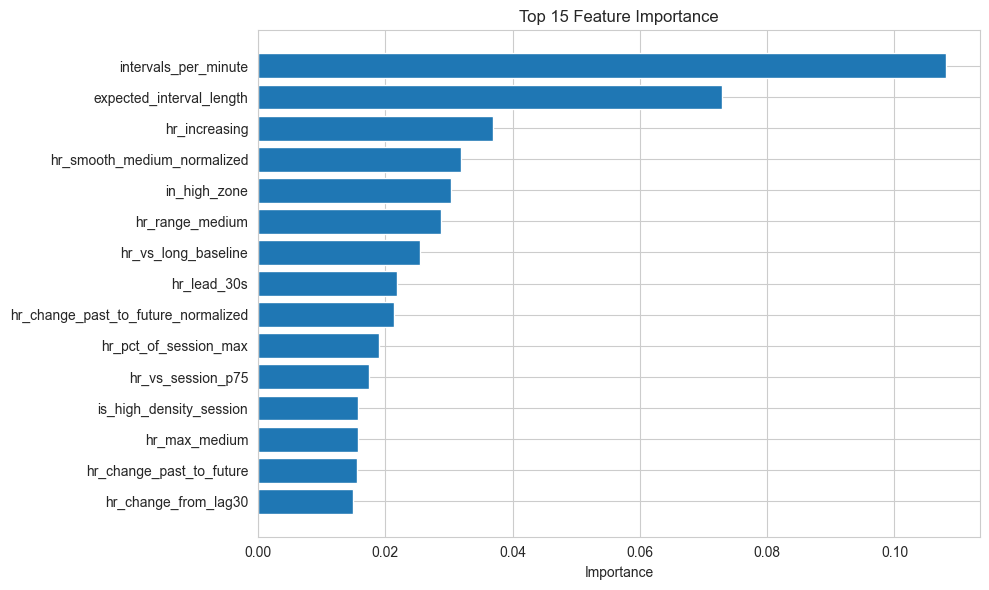

In [16]:
if hasattr(model, 'feature_importances_'):
    feature_names = test_sessions_data[0]['feature_names']
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n🔝 Top 10 Most Important Features:")
    for idx, row in importance_df.head(10).iterrows():
        print(f"   {row['feature']:30s} {row['importance']:.4f}")
    
    # Plot
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(15)
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 13. Visualize All Test Sessions

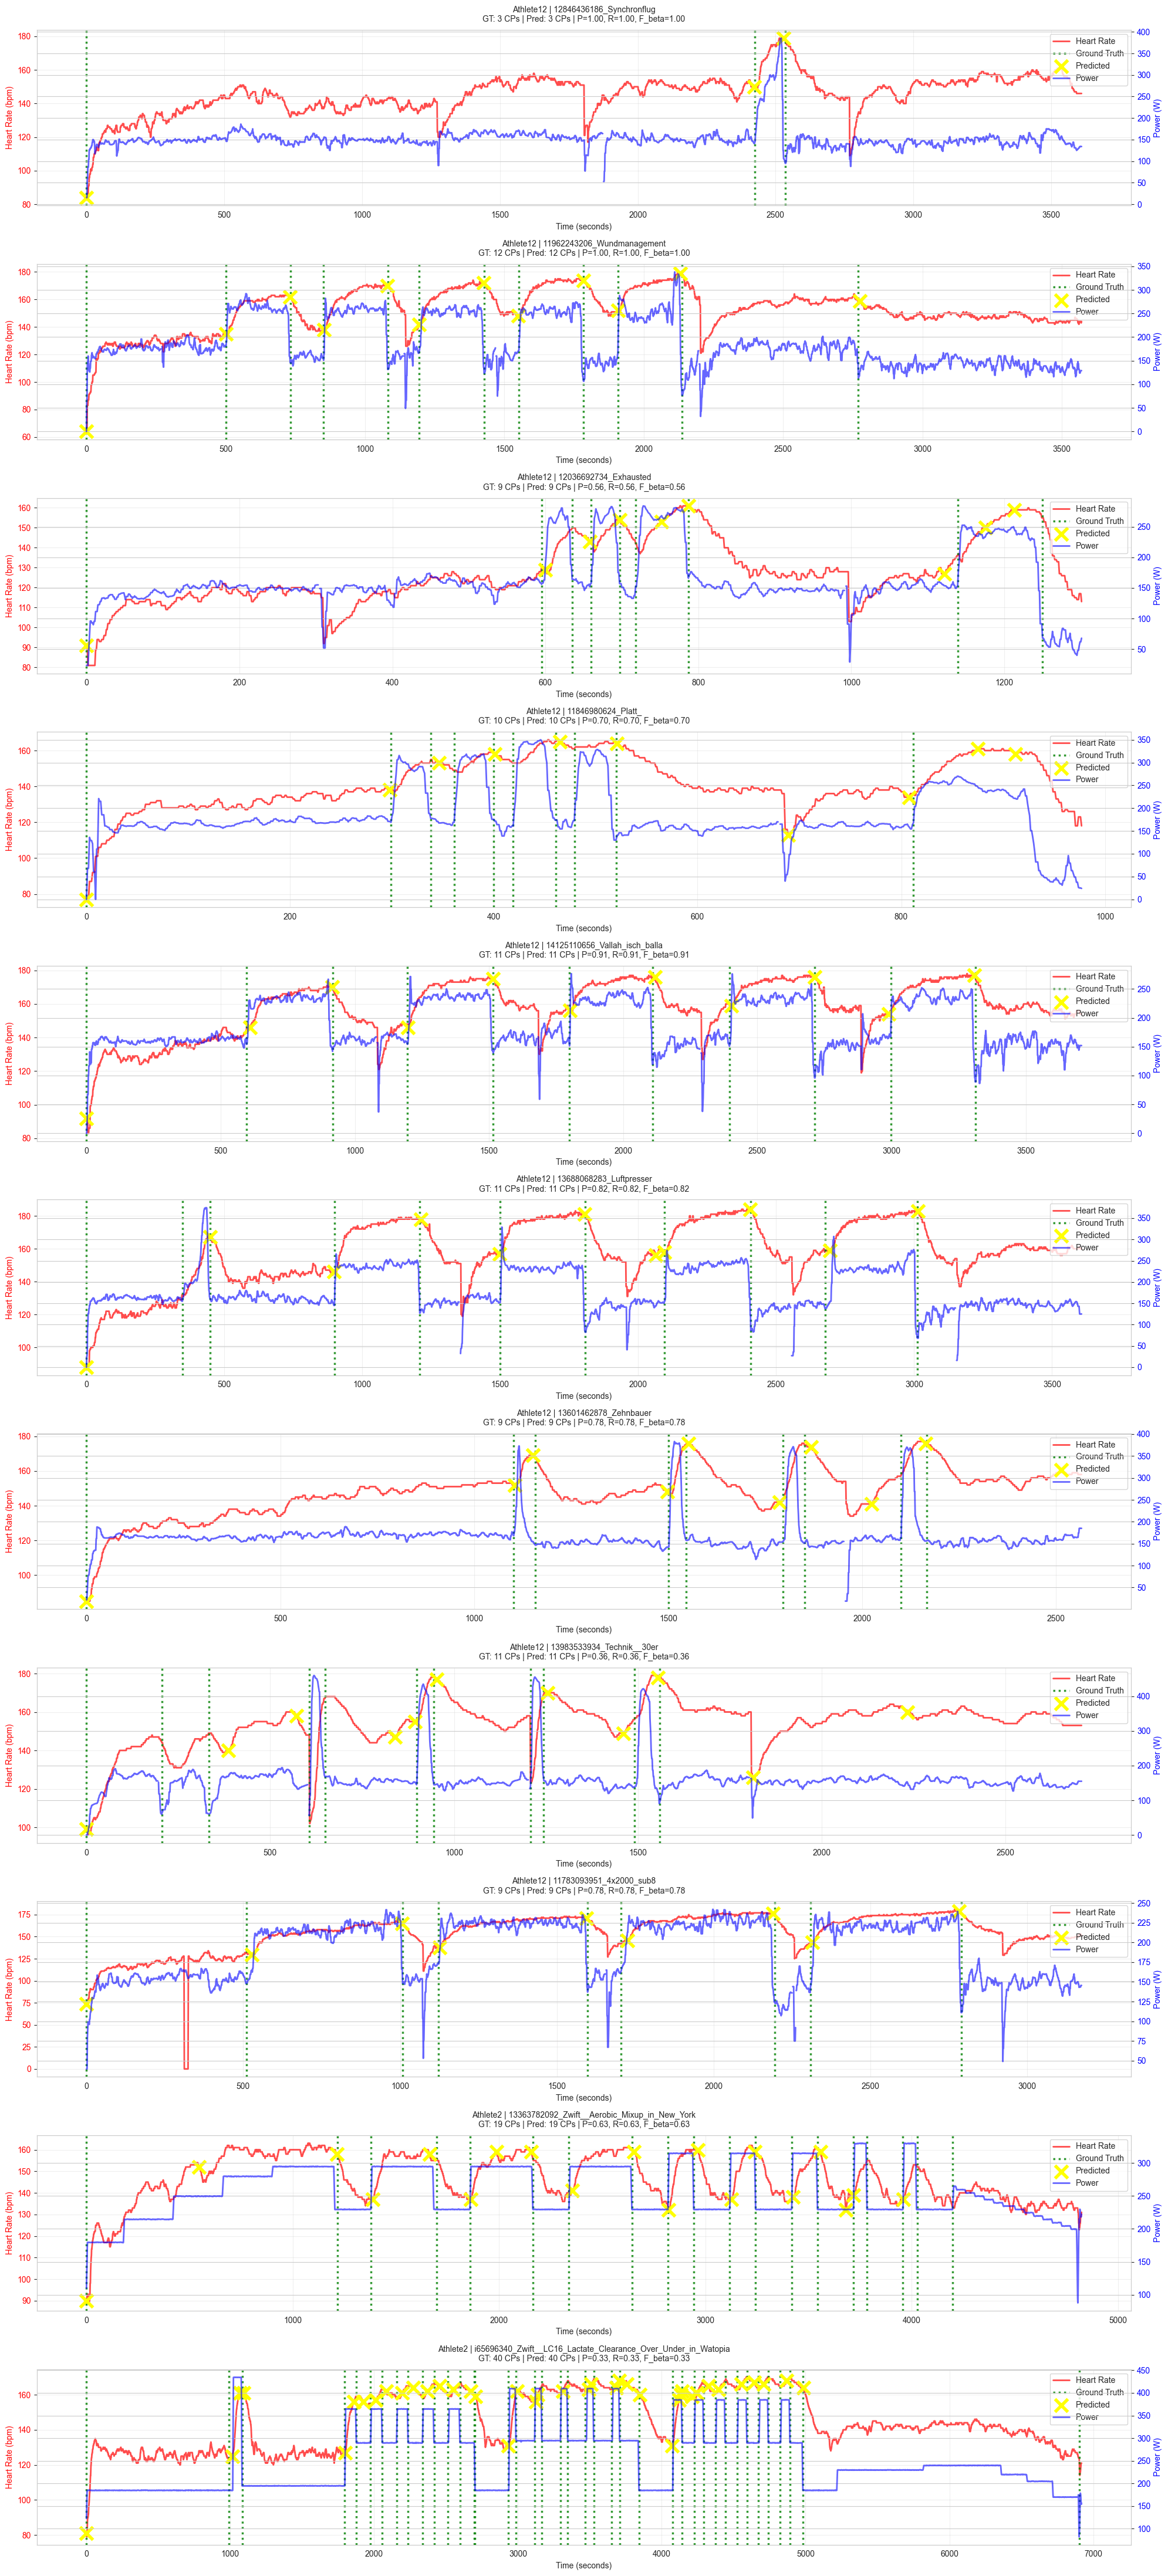

In [14]:
# Create subplots for all test sessions
n_sessions = len(test_results)
fig, axes = plt.subplots(n_sessions, 1, figsize=(20, 4*n_sessions))

# Handle case where there's only one session
if n_sessions == 1:
    axes = [axes]

for idx, result in enumerate(test_results):
    df = result['df']
    y_true = result['y_true']
    y_pred = result['y_pred']
    
    hr_values = df['heart_rate'].values
    
    # Create twin axis for power
    ax1 = axes[idx]
    ax2 = ax1.twinx()

    # Plot heart rate on left axis (RED)
    ax1.plot(hr_values, label='Heart Rate', color='red', alpha=0.7, linewidth=2)

    # Plot power on right axis (BLUE)
    if 'power' in df.columns:
        power_values = df['power'].values
        ax2.plot(power_values, label='Power', color='blue', alpha=0.6, linewidth=2)
        ax2.set_ylabel('Power (W)', fontsize=10, color='blue')
        ax2.tick_params(axis='y', labelcolor='blue')

    # Get change points
    gt_cps = np.where(y_true == 1)[0]
    pred_cps = np.where(y_pred == 1)[0]

    # Mark ground truth change points with GREEN vertical dotted lines
    for cp in gt_cps:
        if cp < len(hr_values):
            ax1.axvline(x=cp, color='green', linestyle=':', linewidth=2.5,
                       alpha=0.8, zorder=4, label='Ground Truth' if cp == gt_cps[0] else '')

    # Mark predicted change points with YELLOW X
    for cp in pred_cps:
        if cp < len(hr_values):
            ax1.scatter(cp, hr_values[cp], marker='x', s=250, color='yellow',
                       linewidths=4, zorder=5, label='Predicted' if cp == pred_cps[0] else '')

    # Set title with session info and metrics
    ax1.set_title(
        f"{result['athlete']} | {result['session']}\n"
        f"GT: {result['n_true']} CPs | Pred: {result['n_pred']} CPs | "
        f"P={result['precision']:.2f}, R={result['recall']:.2f}, F_beta={result['f_beta']:.2f}",
        fontsize=10, pad=10
    )

    ax1.set_ylabel('Heart Rate (bpm)', fontsize=10, color='red')
    ax1.set_xlabel('Time (seconds)', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='red')
    ax1.grid(True, alpha=0.3)

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    if 'power' in df.columns:
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
    else:
        ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 14. Summary Statistics


✓ Created df_results with 11 test sessions
   Sports breakdown:
     rowing: 9 sessions
     biking: 2 sessions

📊 Preview of df_results:
     athlete                        session   sport  n_intervals    f_beta  \
0  Athlete12       12846436186_Synchronflug  rowing            3  1.000000   
1  Athlete12     11962243206_Wundmanagement  rowing           12  1.000000   
2  Athlete12          12036692734_Exhausted  rowing            9  0.555556   
3  Athlete12             11846980624_Platt_  rowing           10  0.700000   
4  Athlete12  14125110656_Vallah_isch_balla  rowing           11  0.909091   

   mean_error_sec  
0        2.000000  
1        1.750000  
2       14.555556  
3       30.500000  
4        4.000000  


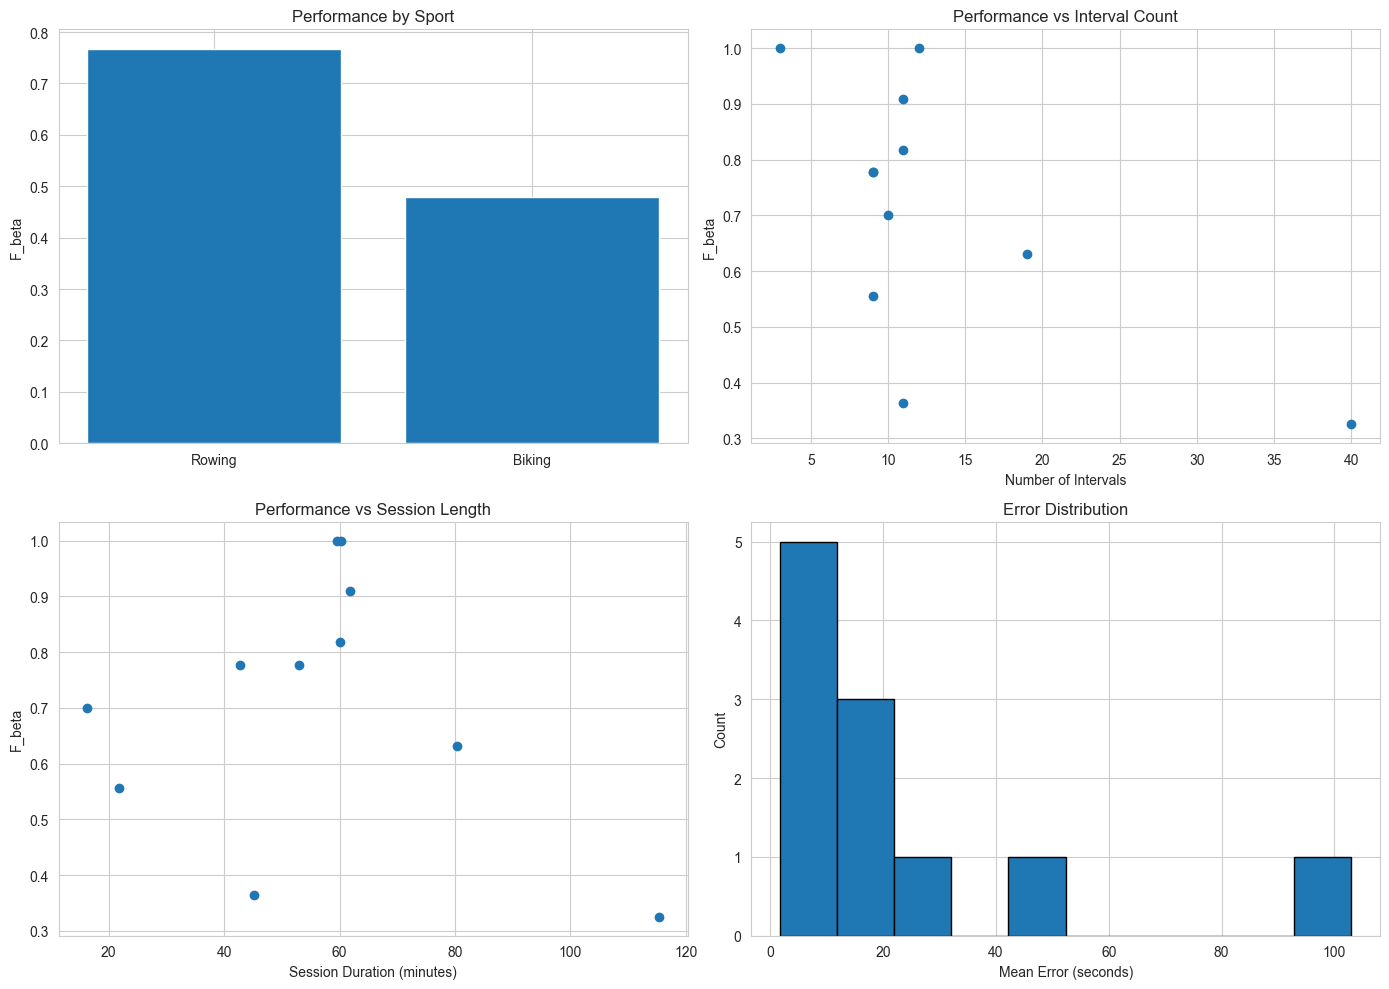

In [18]:
import matplotlib.pyplot as plt
# Create df_results from test_results
import pandas as pd

# Create a mapping from athlete name to sport
athlete_sport_mapping = {
    athlete_name: athlete_data['sport']
    for athlete_name, athlete_data in athletes.items()
}

df_results = pd.DataFrame([
    {
        'athlete': r['athlete'],
        'session': r['session'],
        'n_intervals': r['n_true'],
        'n_pred': r['n_pred'],
        'f_beta': r['f_beta'],
        'precision': r['precision'],
        'recall': r['recall'],
        'mean_error_sec': r['mean_error_sec'],
        'duration_sec': len(r['y_true']),
        'duration_min': len(r['y_true']) / 60,
        'sport': athlete_sport_mapping.get(r['athlete'], 'unknown')
    }
    for r in test_results
])

print(f"\n✓ Created df_results with {len(df_results)} test sessions")
print(f"   Sports breakdown:")
for sport, count in df_results['sport'].value_counts().items():
    print(f"     {sport}: {count} sessions")

print(f"\n📊 Preview of df_results:")
print(df_results[['athlete', 'session', 'sport', 'n_intervals', 'f_beta', 'mean_error_sec']].head())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. F_beta by sport
axes[0, 0].bar(['Rowing', 'Biking'],
               [df_results[df_results['sport']=='rowing']['f_beta'].mean(),
                df_results[df_results['sport']=='biking']['f_beta'].mean()])
axes[0, 0].set_ylabel('F_beta')
axes[0, 0].set_title('Performance by Sport')

# 2. F_beta vs number of intervals
axes[0, 1].scatter(df_results['n_intervals'], df_results['f_beta'])
axes[0, 1].set_xlabel('Number of Intervals')
axes[0, 1].set_ylabel('F_beta')
axes[0, 1].set_title('Performance vs Interval Count')

# 3. F_beta vs session duration
axes[1, 0].scatter(df_results['duration_min'], df_results['f_beta'])
axes[1, 0].set_xlabel('Session Duration (minutes)')
axes[1, 0].set_ylabel('F_beta')
axes[1, 0].set_title('Performance vs Session Length')

# 4. Error distribution
axes[1, 1].hist(df_results['mean_error_sec'], bins=10, edgecolor='black')
axes[1, 1].set_xlabel('Mean Error (seconds)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Error Distribution')

plt.tight_layout()
plt.show()